Assignment 1: ANN Fundamentals - Building from Scratch
Implementing Artificial Neural Networks from Scratch using NumPy

In [150]:
#Step 1 :-> Import Libraries
import numpy as np#to perform the operations on the arrays
import pandas as pd#to load the dataset
import matplotlib.pyplot as plt#to plot the graphs
import seaborn as sns

from sklearn.datasets import load_iris#to load the iris dataset
from sklearn.model_selection import train_test_split#to split the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler#to scale the features



In [151]:
#Step 2 :-> Load the Dataset
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)


(150, 4)
(150,)


In [152]:
#Step 3 :-> Explore the Dataset
print(iris.feature_names)
print(iris.target_names)
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df.head()

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [153]:
#Step 4 :-> Perform EDA

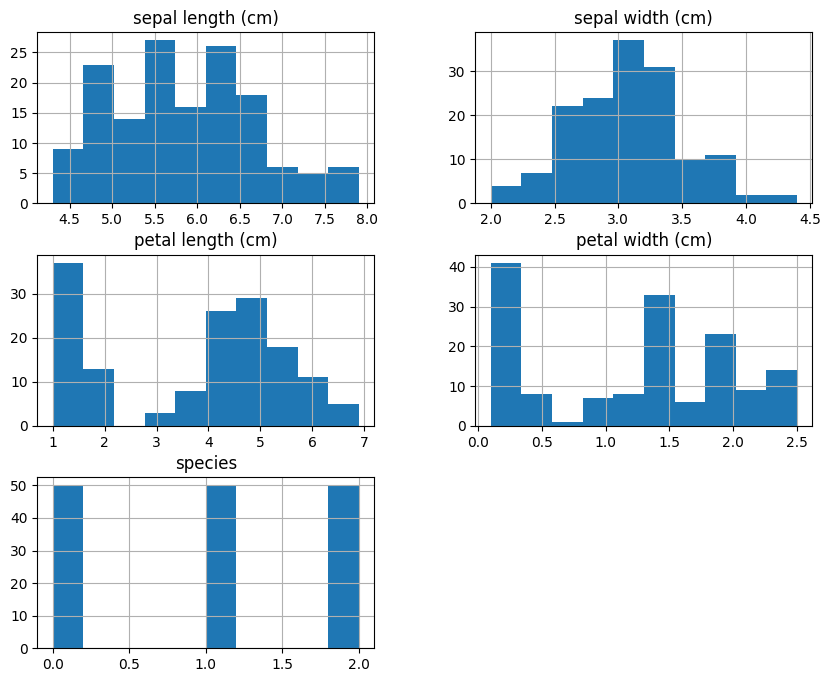

In [154]:
df.hist(figsize=(10,8))
plt.show()

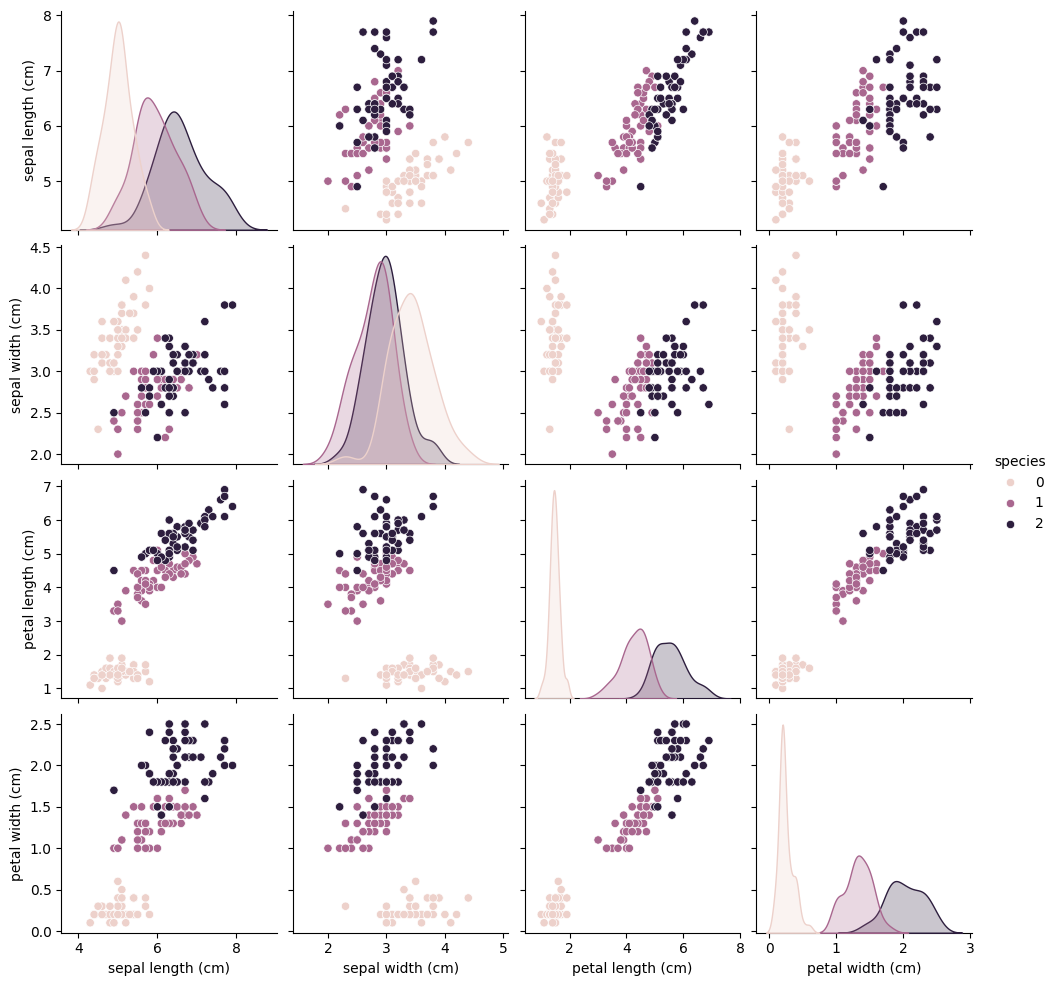

In [155]:
sns.pairplot(df, hue="species")
plt.show()

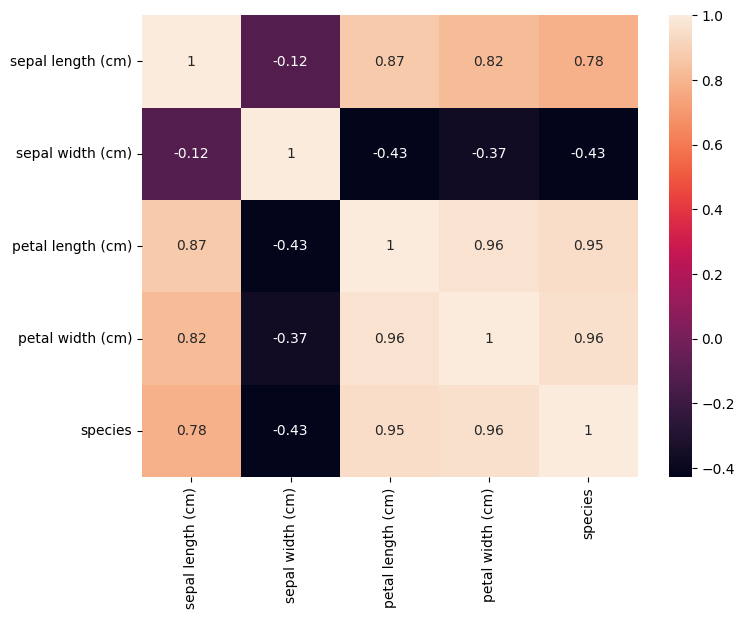

In [156]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [157]:
#STEP 5 :-> Spit the Dataset

In [158]:
#First Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [159]:
#Second Split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(105, 4)
(22, 4)
(23, 4)


In [160]:
#Step 6 :-> Standardize the Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [161]:
#STEP 7 :-> One Hot Encoding
def one_hot_encode(y, num_classes):
    encoded = np.zeros((len(y), num_classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded
y_train_encoded = one_hot_encode(y_train, 3)
y_val_encoded = one_hot_encode(y_val, 3)
y_test_encoded = one_hot_encode(y_test, 3)

In [162]:
#STEP 8 :-> Initialize the Parameters
import numpy as np

def initialize_parameters():

    np.random.seed(42)

    W1 = np.random.randn(4, 8) * 0.5
    b1 = np.zeros((1, 8))

    W2 = np.random.randn(8, 6) * 0.5
    b2 = np.zeros((1, 6))

    W3 = np.random.randn(6, 3) * 0.5
    b3 = np.zeros((1, 3))

    return {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
        "W3": W3,
        "b3": b3
    }
parameters = initialize_parameters()

print("W1 Shape:", parameters["W1"].shape)
print("b1 Shape:", parameters["b1"].shape)

print("W2 Shape:", parameters["W2"].shape)
print("b2 Shape:", parameters["b2"].shape)

print("W3 Shape:", parameters["W3"].shape)
print("b3 Shape:", parameters["b3"].shape)

W1 Shape: (4, 8)
b1 Shape: (1, 8)
W2 Shape: (8, 6)
b2 Shape: (1, 6)
W3 Shape: (6, 3)
b3 Shape: (1, 3)


In [163]:
#STEP 8 :-> Sigmoid Activation Function
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))
print(sigmoid(0))

0.5


In [164]:
#STEP 9 :-> Sigmoid Derivative
def sigmoid_derivative(A):
    return A * (1 - A)
A = sigmoid(0)

print(sigmoid_derivative(A))

0.25


In [165]:
#STEP 10 :-> Softmax Activation Function
def softmax(Z):

    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))

    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
Z = np.array([[2.0, 1.0, 0.1]])

print(softmax(Z))
print(np.sum(softmax(Z)))

[[0.65900114 0.24243297 0.09856589]]
1.0


In [166]:
#STEP 11 :-> Forward Propagation



def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]

    W2 = parameters["W2"]
    b2 = parameters["b2"]

    W3 = parameters["W3"]
    b3 = parameters["b3"]

    # Layer 1
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    # Layer 2
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Output Layer
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3
    }

    return A3, cache
parameters = initialize_parameters()
A3, cache = forward_propagation(X_train, parameters)
print(A3.shape)

(105, 3)


In [167]:
#STEP 12 :-> Compute the Loss
def compute_loss(A3, Y):

    m = Y.shape[0]

    loss = -np.sum(Y * np.log(A3 + 1e-8)) / m

    return loss
A3, cache = forward_propagation(X_train, parameters)

loss = compute_loss(A3, y_train_encoded)

print(loss)

1.0869471358038363


In [168]:
#STEP 13 :-> Backward Propagation
def backward_propagation(X, Y, parameters, cache):

    m = X.shape[0]

    W2 = parameters["W2"]
    W3 = parameters["W3"]

    A1 = cache["A1"]
    A2 = cache["A2"]
    A3 = cache["A3"]

    # Output Layer

    dZ3 = A3 - Y

    dW3 = (1/m) * np.dot(A2.T, dZ3)

    db3 = (1/m) * np.sum(dZ3,
                          axis=0,
                          keepdims=True)

    # Hidden Layer 2

    dA2 = np.dot(dZ3, W3.T)

    dZ2 = dA2 * sigmoid_derivative(A2)



    dW2 = (1/m) * np.dot(A1.T, dZ2)

    db2 = (1/m) * np.sum(dZ2,
                          axis=0,
                          keepdims=True)

    # Hidden Layer 1

    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * sigmoid_derivative(A1)

    dW1 = (1/m) * np.dot(X.T, dZ1)

    db1 = (1/m) * np.sum(dZ1,
                          axis=0,
                          keepdims=True)

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2,
        "dW3": dW3,
        "db3": db3
    }

    return gradients
gradients = backward_propagation(
    X_train,
    y_train_encoded,
    parameters,
    cache
)

print(gradients["dW1"].shape)
print(gradients["dW2"].shape)
print(gradients["dW3"].shape)

(4, 8)
(8, 6)
(6, 3)


In [169]:
#STEP 14 :-> Update Parameters
def update_parameters(parameters,
                      gradients,
                      learning_rate):

    parameters["W1"] -= learning_rate * gradients["dW1"]
    parameters["b1"] -= learning_rate * gradients["db1"]

    parameters["W2"] -= learning_rate * gradients["dW2"]
    parameters["b2"] -= learning_rate * gradients["db2"]

    parameters["W3"] -= learning_rate * gradients["dW3"]
    parameters["b3"] -= learning_rate * gradients["db3"]

    return parameters
parameters = update_parameters(
    parameters,
    gradients,
    0.01
)

In [170]:
#STEPM 15 :-. PREDICTION FUNCTION
def predict(X, parameters):

    A3, _ = forward_propagation(X, parameters)

    predictions = np.argmax(A3, axis=1)

    return predictions
predictions = predict(X_train, parameters)

print(predictions[:10])

[2 2 2 2 2 2 2 2 2 2]


In [171]:
#STEP 16 :-> Calculate Accuracy
def compute_accuracy(y_true, y_pred):

    accuracy = np.mean(y_true == y_pred)

    return accuracy
acc = compute_accuracy(y_train, predictions)

print(acc)

0.3333333333333333


In [172]:
#Step 17 :-> Train the Model
def train_model(
        X_train,
        y_train_encoded,
        y_train,
        X_val,
        y_val,
        epochs=1000,
        learning_rate=0.1):

    parameters = initialize_parameters()

    train_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # Forward Propagation
        A3, cache = forward_propagation(
            X_train,
            parameters
        )

        # Compute Loss
        loss = compute_loss(
            A3,
            y_train_encoded
        )

        # Backward Propagation
        gradients = backward_propagation(
            X_train,
            y_train_encoded,
            parameters,
            cache
        )

        # Update Parameters
        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

        # Track every 50 epochs
        if epoch % 50 == 0:

            # Training Accuracy
            train_predictions = predict(
                X_train,
                parameters
            )

            train_accuracy = compute_accuracy(
                y_train,
                train_predictions
            )

            # Validation Accuracy
            val_predictions = predict(
                X_val,
                parameters
            )

            val_accuracy = compute_accuracy(
                y_val,
                val_predictions
            )

            train_losses.append(loss)
            train_accuracies.append(train_accuracy)
            val_accuracies.append(val_accuracy)

            print(
                f"Epoch {epoch} | "
                f"Loss: {loss:.4f} | "
                f"Train Accuracy: {train_accuracy:.4f} | "
                f"Val Accuracy: {val_accuracy:.4f}"
            )

    return (
        parameters,
        train_losses,
        train_accuracies,
        val_accuracies
    )
parameters, train_losses, train_accuracies, val_accuracies = train_model(
    X_train,
    y_train_encoded,
    y_train,
    X_val,
    y_val,
    epochs=1000,
    learning_rate=0.1
)

Epoch 0 | Loss: 1.0869 | Train Accuracy: 0.3333 | Val Accuracy: 0.3182
Epoch 50 | Loss: 1.0214 | Train Accuracy: 0.7810 | Val Accuracy: 0.7727
Epoch 100 | Loss: 0.9216 | Train Accuracy: 0.7714 | Val Accuracy: 0.8182
Epoch 150 | Loss: 0.7957 | Train Accuracy: 0.8381 | Val Accuracy: 0.8636
Epoch 200 | Loss: 0.6791 | Train Accuracy: 0.8571 | Val Accuracy: 0.8636
Epoch 250 | Loss: 0.5894 | Train Accuracy: 0.8571 | Val Accuracy: 0.8636
Epoch 300 | Loss: 0.5237 | Train Accuracy: 0.8952 | Val Accuracy: 0.8636
Epoch 350 | Loss: 0.4740 | Train Accuracy: 0.9048 | Val Accuracy: 0.8636
Epoch 400 | Loss: 0.4339 | Train Accuracy: 0.9048 | Val Accuracy: 0.8636
Epoch 450 | Loss: 0.3993 | Train Accuracy: 0.9143 | Val Accuracy: 0.9091
Epoch 500 | Loss: 0.3682 | Train Accuracy: 0.9238 | Val Accuracy: 0.9091
Epoch 550 | Loss: 0.3396 | Train Accuracy: 0.9238 | Val Accuracy: 0.9091
Epoch 600 | Loss: 0.3131 | Train Accuracy: 0.9238 | Val Accuracy: 0.9091
Epoch 650 | Loss: 0.2886 | Train Accuracy: 0.9333 | Va

In [173]:
#Step 18 :-> Train the Model

test_predictions = predict(X_test, parameters)


test_accuracy = compute_accuracy(
    y_test,
    test_predictions
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 1.0


In [174]:
#Step 19 :-> Classification Report

from sklearn.metrics import classification_report

test_predictions = predict(X_test, parameters)

print(classification_report(y_test, test_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



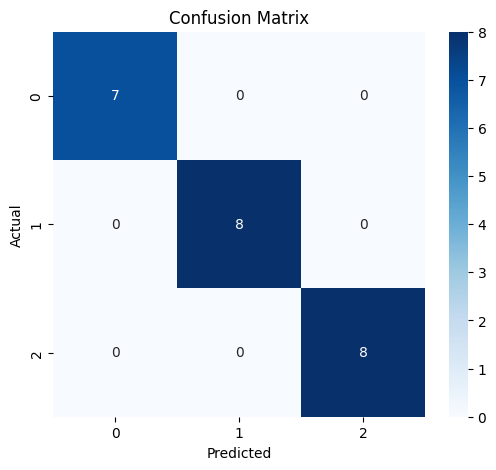

In [175]:
#Step 20 :-> Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


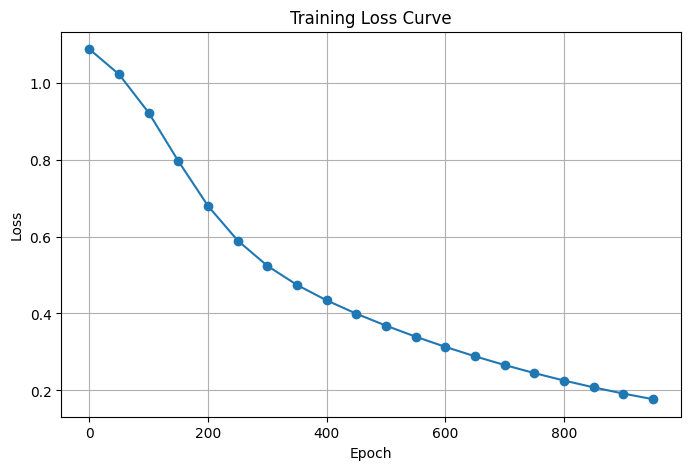

In [176]:
#STEP 21 :-> Plot LOSS Curves
plt.figure(figsize=(8,5))

plt.plot(
    range(0, 1000, 50),
    train_losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid(True)
plt.show()

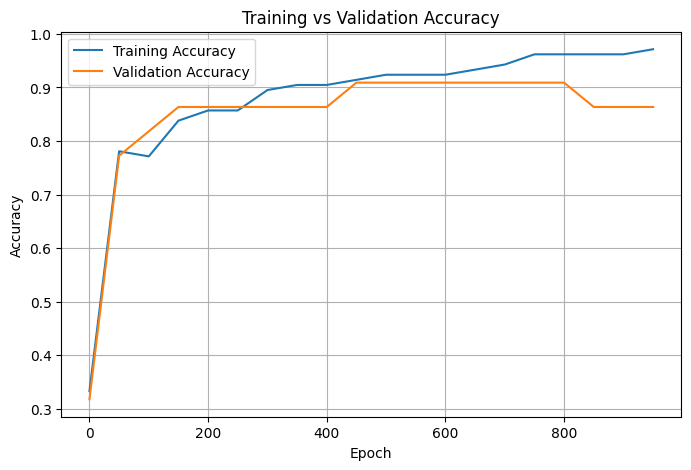

In [177]:
#STEP 22 -> Plot Accuracy Curves
plt.figure(figsize=(8,5))

epochs = range(0, 1000, 50)

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [178]:
#STEP 23 -> COMPARE WITH SKLEARN MLP CLASSIFICATION
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(
    hidden_layer_sizes=(8,6),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

sk_predictions = mlp.predict(X_test)

sk_accuracy = accuracy_score(
    y_test,
    sk_predictions
)

print("Scratch ANN Accuracy:", test_accuracy)
print("Sklearn MLP Accuracy:", sk_accuracy)

Scratch ANN Accuracy: 1.0
Sklearn MLP Accuracy: 0.9565217391304348


In [179]:
#PCA VISUALIZATION
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(X_train_pca.shape)

(105, 2)


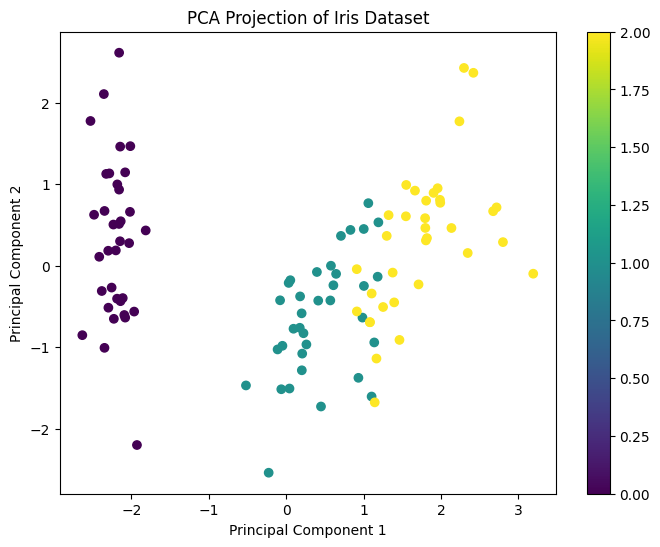

In [180]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")

plt.colorbar(scatter)
plt.show()

In [181]:
#ACTIVATED FUNCTION EXPERIMENTS(tanh)
def tanh(Z):
    return np.tanh(Z)

def tanh_derivative(A):
    return 1 - A**2

In [182]:
#ACTIVATED FUNCTION EXPERIMENTS(relu)
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)